![earthkit-hydro-logo](https://github.com/ecmwf/logos/raw/refs/heads/main/logos/earthkit/earthkit-hydro-light.svg)

# Earthkit-hydro: Computing Accumulations Along River Networks

Tnis notebook will show a simple example of computing global and local accumulations along river networks.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import earthkit.hydro as ekh

First, we load the relevant data needed for the notebook.

In [2]:
# load an example precipitation dataset
da = ekd.from_source(
    "sample",
    "R06a.nc",
).to_xarray()["R06a"].isel(time=0).load() # making sure it's not chunked in space
print(da)

# some nice custom plots styles
style = ekp.styles.Style(
    colors="Blues",
    levels=[0, 0.5, 1, 2, 5, 10, 50, 100, 500, 1000, 2000, 3000, 4000],
    extend="max",
)

# load the river network
network = ekh.river_network.load("efas", "5")

<xarray.DataArray 'R06a' (lat: 2970, lon: 4530)> Size: 54MB
array([[0.06744136, 0.06995939, 0.08337583, ...,        nan,        nan,
               nan],
       [0.0870114 , 0.08831516, 0.08961891, ...,        nan,        nan,
               nan],
       [0.11274368, 0.1154278 , 0.11811192, ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan,        nan, ..., 0.        , 0.        ,
        0.        ],
       [       nan,        nan,        nan, ..., 0.        , 0.        ,
        0.        ],
       [       nan,        nan,        nan, ..., 0.        , 0.        ,
        0.        ]], shape=(2970, 4530), dtype=float32)
Coordinates:
  * lat      (lat) float64 24kB 72.24 72.22 72.21 72.19 ... 22.79 22.77 22.76
  * lon      (lon) float64 36kB -25.24 -25.23 -25.21 ... 50.21 50.22 50.24
    time     datetime64[ns] 8B 2024-11-14T06:00:00
Attributes:
    units:          mm
    standard_name:  precipitation
    long_name:      precipitation
River ne

There are two different categories of accumulations in earthkit-hydro.
1. full flow accumulations (global aggregation)
2. one-step neighbor accumulations (local aggregation).

## Global aggregation

Global aggregations from sources to sinks can computed via the `ekh.upstream` submodule, and aggregations from sinks to sources can be computed using the `ekh.downstream` submodule.

Many different aggregations are possible, namely `sum`, `min`, `max`, `mean`, `var`, `std`.

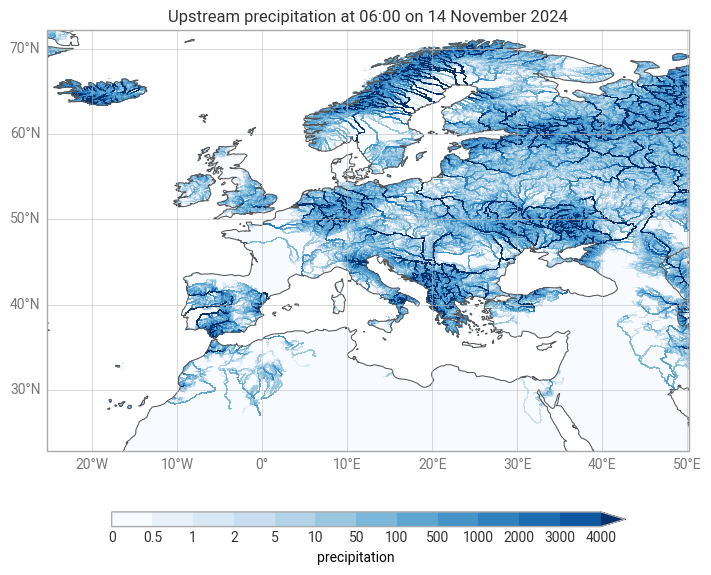

In [3]:
upstream_sum = ekh.upstream.sum(network, da)

chart = ekp.Map()
chart.quickplot(upstream_sum, style=style)
chart.legend(label="{variable_name}")
chart.title("Upstream precipitation at {time:%H:%M on %-d %B %Y}")
chart.coastlines()
chart.gridlines()
chart.show()

## Local aggregation

Local aggregations can be computed using the `move` submodule, and the same metrics are available.

Below we show an example using `move.downstream` to find the number of gridcells draining to each point.

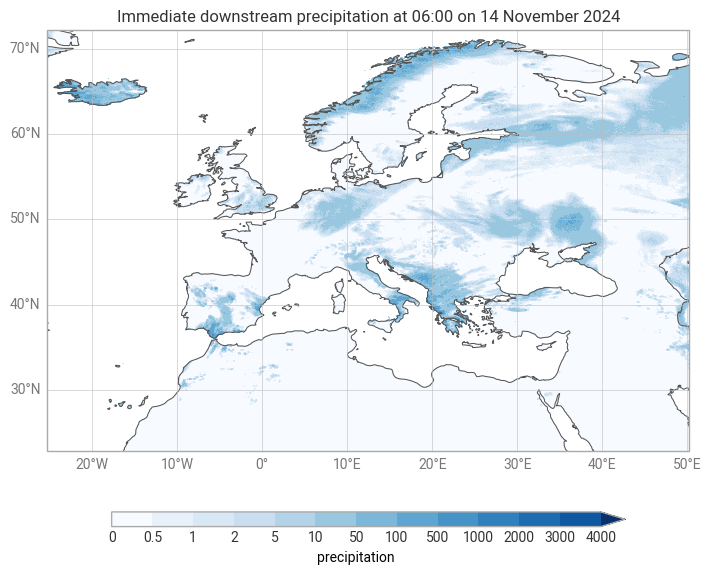

In [4]:
move_downstream = ekh.move.downstream(network, da, metric="sum")

chart = ekp.Map()
chart.quickplot(move_downstream, style=style)
chart.legend(label="{variable_name}")
chart.title("Immediate downstream precipitation at {time:%H:%M on %-d %B %Y}")
chart.coastlines()
chart.gridlines()
chart.show()